In [6]:
from google.colab import files
uploaded = files.upload()

Saving Global Carbon Project 2.0 (2).xlsx to Global Carbon Project 2.0 (2) (3).xlsx


✅ Found File: Global Carbon Project 2.0 (2) (1).xlsx


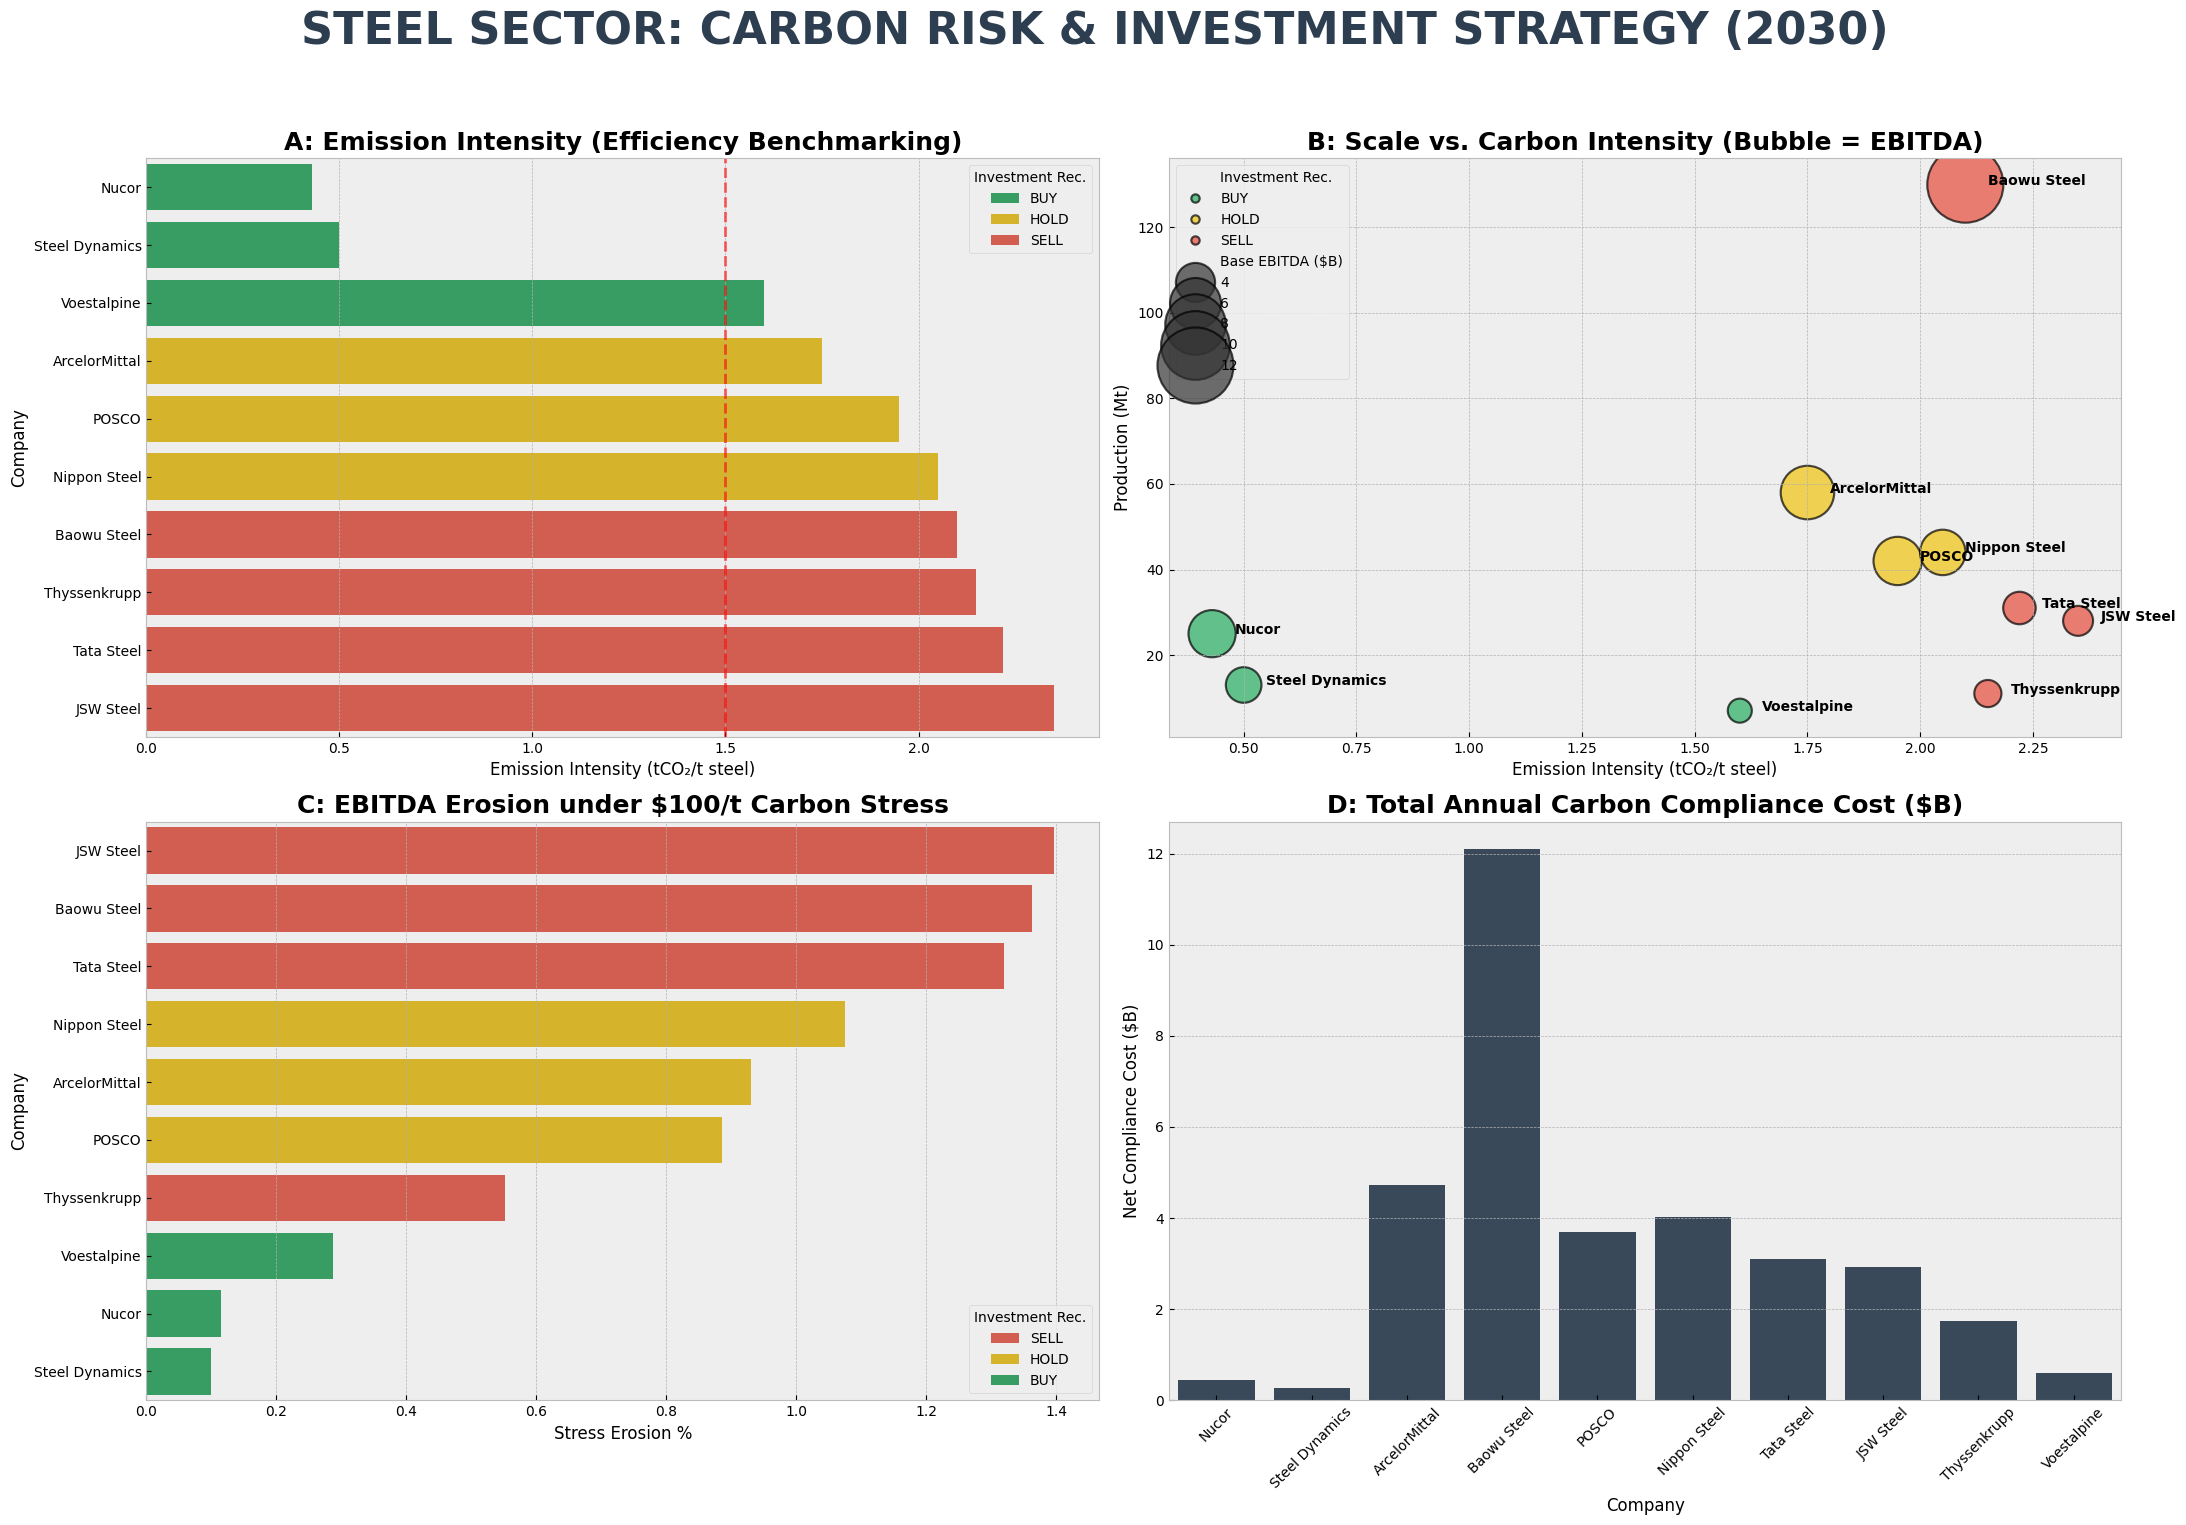

🚀 SUCCESS! Your dashboard is saved as 'Professional_Steel_Dashboard.png'


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. FIND THE EXCEL FILE
# This part automatically finds your Excel file even if the name is slightly different
excel_files = [f for f in os.listdir('.') if f.endswith('.xlsx')]

if not excel_files:
    print("❌ ERROR: I can't see the Excel file. Please upload it to the folder on the left!")
else:
    file_name = excel_files[0]
    print(f"✅ Found File: {file_name}")

    # 2. LOAD THE SHEETS (The 'Tabs' in your Excel)
    # We load them directly from the original file
    df_company = pd.read_excel(file_name, sheet_name='Company Data & Assumptions')
    df_risk = pd.read_excel(file_name, sheet_name='Carbon Risk Engine')
    df_thesis = pd.read_excel(file_name, sheet_name='Investment Thesis')

    # 3. PROFESSIONAL CLEANING
    # This strips hidden spaces from column names so the code doesn't crash
    for df in [df_company, df_risk, df_thesis]:
        df.columns = df.columns.str.strip()

    # 4. MERGE DATA (Combining the sheets)
    df_master = df_company[['Company', 'Production (Mt)', 'Emission Intensity (tCO₂/t steel)', 'Base EBITDA ($B)']].merge(
        df_risk[['Company', 'Net Compliance Cost ($B)', 'Stress Erosion %']], on='Company').merge(
        df_thesis[['Company', 'Investment Rec.']], on='Company')

    # 5. CREATE THE DASHBOARD
    plt.style.use('bmh') # Professional 'Business' style
    fig, axes = plt.subplots(2, 2, figsize=(22, 16), facecolor='#ffffff')
    fig.suptitle('STEEL SECTOR: CARBON RISK & INVESTMENT STRATEGY (2030)',
                 fontsize=32, fontweight='bold', color='#2c3e50', y=0.98)

    # Professional Color Palette
    status_colors = {'BUY': '#27ae60', 'HOLD': '#f1c40f', 'SELL': '#e74c3c'}

    # --- CHART A: Carbon Intensity ---
    sns.barplot(ax=axes[0, 0], x='Emission Intensity (tCO₂/t steel)', y='Company',
                data=df_master.sort_values('Emission Intensity (tCO₂/t steel)'),
                hue='Investment Rec.', palette=status_colors, dodge=False)
    axes[0, 0].set_title('A: Emission Intensity (Efficiency Benchmarking)', fontsize=18, fontweight='bold')
    axes[0, 0].axvline(1.5, color='red', linestyle='--', alpha=0.6)

    # --- CHART B: Strategic Exposure (Bubble Chart) ---
    sns.scatterplot(ax=axes[0, 1], x='Emission Intensity (tCO₂/t steel)', y='Production (Mt)',
                    size='Base EBITDA ($B)', sizes=(300, 3000), hue='Investment Rec.',
                    palette=status_colors, data=df_master, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('B: Scale vs. Carbon Intensity (Bubble = EBITDA)', fontsize=18, fontweight='bold')
    for i in range(df_master.shape[0]):
        axes[0, 1].text(df_master['Emission Intensity (tCO₂/t steel)'][i]+0.05,
                        df_master['Production (Mt)'][i], df_master['Company'][i], weight='bold')

    # --- CHART C: Margin Erosion ---
    sns.barplot(ax=axes[1, 0], x='Stress Erosion %', y='Company',
                data=df_master.sort_values('Stress Erosion %', ascending=False),
                hue='Investment Rec.', palette=status_colors, dodge=False)
    axes[1, 0].set_title('C: EBITDA Erosion under $100/t Carbon Stress', fontsize=18, fontweight='bold')

    # --- CHART D: Total Liability ---
    sns.barplot(ax=axes[1, 1], x='Company', y='Net Compliance Cost ($B)', data=df_master, color='#34495e')
    axes[1, 1].set_title('D: Total Annual Carbon Compliance Cost ($B)', fontsize=18, fontweight='bold')
    plt.xticks(rotation=45)

    # 6. SAVE AND FINISH
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('Professional_Steel_Dashboard.png', dpi=300)
    plt.show()
    print("🚀 SUCCESS! Your dashboard is saved as 'Professional_Steel_Dashboard.png'")